## __Bug Tracking & Sprint Quality Analytics__

The dataset is an software engineering quality assurance and issue-tracking log contains 3,690 bug records across 30 attributes, representing software issue tracking, testing execution, agile sprint delivery, and defect lifecycle metrics.

 __Problem Statement :__
 
Software engineering and product teams generate vast amounts of defect and ticket data during development cycles. However, without systematic analysis, identifying recurring resolution bottlenecks, root causes, and quality leaks into production environments becomes difficult. This lack of visibility can lead to extended resolution times, increased development costs, repeated defect reopenings, and degraded end-user experience.

The Objective of the project is to 

 •	Find bottlenecks by checking fix times (resolution_days) across severities and teams.
 
 •	Identify why bugs happen 
 
 •	Measure how many bugs escaped to production and evaluate their impact on customers.
 
 •	Calculate test failure rates and compare defect counts across environments (Dev, QA, Staging, Production)


__Dataset Contains 3690 Rows and 30 Columns__

### __Data Cleaning & Preprocessing__

 Imports the essential numerical and data manipulation libraries (numpy and pandas)

In [2]:
import numpy as np
import pandas as pd

The dataset __bug_tracking_dataset.csv__ is loaded into a Pandas DataFrame using __pd.read_csv()__

In [3]:
df = pd.read_csv("bug_tracking_dataset.csv")
df

,record_id,bug_id,project,sprint,issue_type,title,severity,priority,status,created_date,...,resolution_days,reopen_count,escaped_to_production,test_cases_executed,failed_test_cases,blocked_hours,customer_impact,root_cause,labels,comments
0,1,BUG-11504,Atlas,Sprint 22,Bug,Data Pipeline issue - slow response,Major,Low,Closed,2025-11-15,...,2.0,0,1,137,12,0.0,NaN,Data Issue,api,duplicate suspected
1,2,BUG-12503,Atlas,Sprint 13,Bug,Web UI issue - layout defect,High,Medium,Open,2025-05-13,...,NaN,1,0,89,2,8.5,Medium,NaN,regression,fixed after config refresh
2,3,BUG-11395,Nova,Sprint 6,Regression,Mobile issue - timeout,Medium,P1,Closed,2026-02-20,...,14.0,1,0,105,8,9.0,Severe,Code Defect,regression,customer escalation
3,4,BUG-12798,Phoenix,Sprint 10,Bug,Search issue - missing data,Medium,Medium,Reopened,2025-02-07,...,21.8,1,1,76,28,0.2,NaN,Data Issue,security,linked to flaky test
4,5,BUG-10648,Nova,Sprint 4,Bug,Payments issue - validation error,High,Medium,Resolved,2025-07-24,...,13.4,0,1,84,17,2.7,NaN,NaN,api,customer escalation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3685,3686,BUG-11123,Orion,Sprint 15,Regression,Web UI issue - validation error,Trivial,High,In Progress,2025-05-18,...,NaN,1,0,62,17,12.6,NaN,Dependency,automation,NaN
3686,3687,BUG-11347,Zephyr,Sprint 4,Bug,API issue - missing data,Minor,Medium,Reopened,2026-02-02,...,21.1,3,0,142,1,6.2,NaN,Requirements Gap,customer-reported,fixed after config refresh
3687,3688,BUG-13455,Zephyr,Sprint 10,Bug,Payments issue - validation error,Minor,Medium,Closed,2025-01-27,...,8.8,0,0,80,2,0.0,Low,Code Defect,regression,duplicate suspected
3688,3689,BUG-13438,Orion,Sprint 8,Bug,Search issue - incorrect total,Major,High,Resolved,2026-07-31,...,31.7,3,0,57,5,2.0,Medium,Requirements Gap,tech-debt,fixed after config refresh


Initial observations of the DataFrame using structural attributes and methods shape,dtypes,head(),tail(),info()and describe()

finding no.of rows and columns using the atribute __df.shape__

In [3]:
df.shape

(3690, 30)

to find data types of each columns we can use __df.dtypes__

In [4]:
df.dtypes

record_id                  int64
bug_id                    object
project                   object
sprint                    object
issue_type                object
title                     object
severity                  object
priority                  object
status                    object
created_date              object
sprint_start              object
sprint_end                object
assignee                  object
reporter                  object
team                      object
module                    object
platform                  object
environment               object
story_points             float64
age_days                   int64
resolution_days          float64
reopen_count               int64
escaped_to_production      int64
test_cases_executed        int64
failed_test_cases          int64
blocked_hours            float64
customer_impact           object
root_cause                object
labels                    object
comments                  object
dtype: obj

head() is used to review sample rows from the top of the DataFrame, by default it shows first 5 rows

In [5]:
df.head()

,record_id,bug_id,project,sprint,issue_type,title,severity,priority,status,created_date,...,resolution_days,reopen_count,escaped_to_production,test_cases_executed,failed_test_cases,blocked_hours,customer_impact,root_cause,labels,comments
0,1,BUG-11504,Atlas,Sprint 22,Bug,Data Pipeline issue - slow response,Major,Low,Closed,2025-11-15,...,2.0,0,1,137,12,0.0,NaN,Data Issue,api,duplicate suspected
1,2,BUG-12503,Atlas,Sprint 13,Bug,Web UI issue - layout defect,High,Medium,Open,2025-05-13,...,NaN,1,0,89,2,8.5,Medium,NaN,regression,fixed after config refresh
2,3,BUG-11395,Nova,Sprint 6,Regression,Mobile issue - timeout,Medium,P1,Closed,2026-02-20,...,14.0,1,0,105,8,9.0,Severe,Code Defect,regression,customer escalation
3,4,BUG-12798,Phoenix,Sprint 10,Bug,Search issue - missing data,Medium,Medium,Reopened,2025-02-07,...,21.8,1,1,76,28,0.2,NaN,Data Issue,security,linked to flaky test
4,5,BUG-10648,Nova,Sprint 4,Bug,Payments issue - validation error,High,Medium,Resolved,2025-07-24,...,13.4,0,1,84,17,2.7,NaN,NaN,api,customer escalation


tail() is used to review sample rows from the bottom of the DataFrame, by default it shows last 5 rows

In [6]:
df.tail()

,record_id,bug_id,project,sprint,issue_type,title,severity,priority,status,created_date,...,resolution_days,reopen_count,escaped_to_production,test_cases_executed,failed_test_cases,blocked_hours,customer_impact,root_cause,labels,comments
3685,3686,BUG-11123,Orion,Sprint 15,Regression,Web UI issue - validation error,Trivial,High,In Progress,2025-05-18,...,NaN,1,0,62,17,12.6,NaN,Dependency,automation,NaN
3686,3687,BUG-11347,Zephyr,Sprint 4,Bug,API issue - missing data,Minor,Medium,Reopened,2026-02-02,...,21.1,3,0,142,1,6.2,NaN,Requirements Gap,customer-reported,fixed after config refresh
3687,3688,BUG-13455,Zephyr,Sprint 10,Bug,Payments issue - validation error,Minor,Medium,Closed,2025-01-27,...,8.8,0,0,80,2,0.0,Low,Code Defect,regression,duplicate suspected
3688,3689,BUG-13438,Orion,Sprint 8,Bug,Search issue - incorrect total,Major,High,Resolved,2026-07-31,...,31.7,3,0,57,5,2.0,Medium,Requirements Gap,tech-debt,fixed after config refresh
3689,3690,BUG-13583,Atlas,Sprint 7,Bug,Reporting issue - validation error,Major,High,Open,2025-04-29,...,13.3,0,0,47,0,0.0,NaN,Dependency,ui,NaN


The info() method in pandas prints a concise summary of a DataFrame. It is useful for initial data exploration, as it quickly reveals the shape of your data, column data types, missing values, and memory usage.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3690 entries, 0 to 3689
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   record_id              3690 non-null   int64  
 1   bug_id                 3690 non-null   object 
 2   project                3690 non-null   object 
 3   sprint                 3690 non-null   object 
 4   issue_type             3690 non-null   object 
 5   title                  3690 non-null   object 
 6   severity               3481 non-null   object 
 7   priority               3523 non-null   object 
 8   status                 3653 non-null   object 
 9   created_date           3690 non-null   object 
 10  sprint_start           3690 non-null   object 
 11  sprint_end             3690 non-null   object 
 12  assignee               3560 non-null   object 
 13  reporter               3690 non-null   object 
 14  team                   3690 non-null   object 
 15  modu

describe() is used to quickly generate summary statistics of a dataframe. it analyzes numeric columns to provide the count, mean, standard deviation, minimum, maximum, and percentiles (25th, 50th, 75th)

In [8]:
df.describe()

,record_id,story_points,age_days,resolution_days,reopen_count,escaped_to_production,test_cases_executed,failed_test_cases,blocked_hours
count,3690.000000,3571.000000,3690.000000,2479.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000
mean,1845.500000,5.320919,18.185366,13.427793,0.615718,0.112195,83.488618,8.374526,6.774580
std,1065.355574,5.165096,38.836261,26.070206,0.901354,0.315649,35.734063,5.894583,16.304409
min,1.000000,0.500000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,923.250000,2.000000,3.000000,6.300000,0.000000,0.000000,59.000000,4.000000,0.000000
50%,1845.500000,5.000000,14.000000,10.400000,0.000000,0.000000,83.000000,8.000000,4.400000
75%,2767.750000,5.000000,26.000000,15.600000,1.000000,0.000000,107.000000,12.000000,10.300000
max,3690.000000,34.000000,829.000000,612.000000,5.000000,1.000000,206.000000,33.000000,498.000000


### __Data Cleaning__

### Duplicate Handling
#### Identify & remove duplicates
Identifies duplicate records using df.duplicated(subset=["bug_id"]) detecting 55 duplicate entries. The duplicate records are dropped using df.drop_duplicates(subset=["bug_id"], keep="first"), reducing the dataset to 3,635 rows

In [4]:
num_duplicates = df.duplicated(subset=["bug_id"]).sum()
print("No.of duplicate records :",num_duplicates)

No.of duplicate records : 55


In [5]:
# removing duplicate records
df=df.drop_duplicates(subset=["bug_id"], keep="first").copy()

verifying the duplicate records are removed using shape atribute

In [6]:
df.shape

(3635, 30)

In [12]:
df.dtypes

record_id                  int64
bug_id                    object
project                   object
sprint                    object
issue_type                object
title                     object
severity                  object
priority                  object
status                    object
created_date              object
sprint_start              object
sprint_end                object
assignee                  object
reporter                  object
team                      object
module                    object
platform                  object
environment               object
story_points             float64
age_days                   int64
resolution_days          float64
reopen_count               int64
escaped_to_production      int64
test_cases_executed        int64
failed_test_cases          int64
blocked_hours            float64
customer_impact           object
root_cause                object
labels                    object
comments                  object
dtype: obj

### Standardizing Text,Categorical and Numerical Values
Fixing inconsistent casing, strip leading or trailing spaces, and map synonymous values.

Standardizing values is necessary because computers treat identical words with different capitalizations or extra spaces as separate categories. Fixing these inconsistencies ensures your data remains clean, accurate, and consistent for reliable analysis

Storing columns having object datatype to __cat_cols__ using __df.select_dtypes(include=["object"]).columns__ and   Loops through object columns to strip leading/trailing whitespace and apply title-casing using __.str.strip().str.title()__

In [7]:
# storing columns having object datatype
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
# Convert to string, trim trailing/leading spaces, and format case
    df[col] = df[col].str.strip().str.title()


Some Bug id contains Bug-Dup values, replace these values using Bug-

In [8]:
df["bug_id"] = df["bug_id"].str.replace("Bug-Dup-", "Bug-", regex=False)

Standardizes priority by mapping 'P0', 'P1', 'P2', and 'P3' to 'Critical', 'High', 'Medium', and 'Low' and replace values in priority column with priority_map using replace()

In [9]:
priority_map = {
    'P0': "Critical",
    'P1': "High",
    'P2': "Medium",
    'P3': "Low"
}
df.loc[:, "priority"] = df["priority"].replace(priority_map)


Standerdizing status using status_map dictionary

In [10]:
status_map = {
    "Resolved":"Closed",
    "Done": "Closed",
    "To Do": "Open"
}
df["status"] = df["status"].replace(status_map)

Standardizes story_points by using .loc

In [11]:
df.loc[df["story_points"] == 0.5, "story_points"] = 1.0
df.loc[df["story_points"] == 9.5, "story_points"] = 8.0

Ceil the values in reopen_count and resolution_days to nearest whole integer and converting the data type to int

In [12]:
df["reopen_count"] = np.ceil(df["reopen_count"]).astype("Int64")
df["resolution_days"] = np.ceil(df["resolution_days"]).astype("Int64")

values in story_points must follow fibonacci series so Replace non-standard values by snapping them to the nearest valid Fibonacci number 

In [13]:
df

,record_id,bug_id,project,sprint,issue_type,title,severity,priority,status,created_date,...,resolution_days,reopen_count,escaped_to_production,test_cases_executed,failed_test_cases,blocked_hours,customer_impact,root_cause,labels,comments
0,1,Bug-11504,Atlas,Sprint 22,Bug,Data Pipeline Issue - Slow Response,Major,Low,Closed,2025-11-15,...,2,0,1,137,12,0.0,NaN,Data Issue,Api,Duplicate Suspected
1,2,Bug-12503,Atlas,Sprint 13,Bug,Web Ui Issue - Layout Defect,High,Medium,Open,2025-05-13,...,<NA>,1,0,89,2,8.5,Medium,NaN,Regression,Fixed After Config Refresh
2,3,Bug-11395,Nova,Sprint 6,Regression,Mobile Issue - Timeout,Medium,High,Closed,2026-02-20,...,14,1,0,105,8,9.0,Severe,Code Defect,Regression,Customer Escalation
3,4,Bug-12798,Phoenix,Sprint 10,Bug,Search Issue - Missing Data,Medium,Medium,Reopened,2025-02-07,...,22,1,1,76,28,0.2,NaN,Data Issue,Security,Linked To Flaky Test
4,5,Bug-10648,Nova,Sprint 4,Bug,Payments Issue - Validation Error,High,Medium,Closed,2025-07-24,...,14,0,1,84,17,2.7,NaN,NaN,Api,Customer Escalation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3685,3686,Bug-11123,Orion,Sprint 15,Regression,Web Ui Issue - Validation Error,Trivial,High,In Progress,2025-05-18,...,<NA>,1,0,62,17,12.6,NaN,Dependency,Automation,NaN
3686,3687,Bug-11347,Zephyr,Sprint 4,Bug,Api Issue - Missing Data,Minor,Medium,Reopened,2026-02-02,...,22,3,0,142,1,6.2,NaN,Requirements Gap,Customer-Reported,Fixed After Config Refresh
3687,3688,Bug-13455,Zephyr,Sprint 10,Bug,Payments Issue - Validation Error,Minor,Medium,Closed,2025-01-27,...,9,0,0,80,2,0.0,Low,Code Defect,Regression,Duplicate Suspected
3688,3689,Bug-13438,Orion,Sprint 8,Bug,Search Issue - Incorrect Total,Major,High,Closed,2026-07-31,...,32,3,0,57,5,2.0,Medium,Requirements Gap,Tech-Debt,Fixed After Config Refresh


### Handling missing values

Missing values are data points that have no stored value or are recorded as blank, null, or NaN.Handling missing values is essential for better analysis.

count the no.of missing values in each column using __isnull()__ and __sum()__

In [14]:
df.isnull().sum()

record_id                   0
bug_id                      0
project                     0
sprint                      0
issue_type                  0
title                       0
severity                  208
priority                  166
status                     36
created_date                0
sprint_start                0
sprint_end                  0
assignee                  129
reporter                    0
team                        0
module                      0
platform                  253
environment               361
story_points              117
age_days                    0
resolution_days          1195
reopen_count                0
escaped_to_production       0
test_cases_executed         0
failed_test_cases           0
blocked_hours               0
customer_impact          1177
root_cause                194
labels                    328
comments                  348
dtype: int64

missing values can be handled by deleting the rows or imputing with values like mean,median,mode,0 and unknown
imputing missing values in severity,priority,status,platform,environment,customer_impact,root_cause,labels,comments using __unknown__ and assignee with __unassigned__ using __fillna()__

In [15]:
cat_columns = ["severity","priority","status","platform","environment","customer_impact","root_cause","labels","comments"]
for col in cat_columns :
    df[col] = df[col].fillna("Unknown")
df["assignee"] = df["assignee"].fillna("Unassigned")

imputing story_points using median value

In [16]:
median_value = df["story_points"].median()
df["story_points"] = df["story_points"].fillna(median_value) 

imputing missing values in resolution_days based on the status

if the status is in-progress impute missing values in resolution_days using age_days

In [17]:
# Fill In Progress using age_days
df.loc[df["status"] == "In Progress", "resolution_days"] = df["resolution_days"].fillna(df["age_days"])

if the status is open impute missing values in resolution_days using age_days

In [18]:
# Impute Open status using age_days
df.loc[df["status"] == "Open", "resolution_days"] = df["resolution_days"].fillna(df["age_days"])

if the status is closed impute missing values using severity and priority median

It filters the dataset for "Closed" tickets and groups them by severity and priority then calculates the median resolution_days for each specific group and impute missing values using median value

In [19]:
# Fill Closed using severity/priority median
median = df[df["status"] == "Closed"].groupby(["severity", "priority"])["resolution_days"].transform("median").round()
df.loc[df["status"] == "Closed", "resolution_days"] = df["resolution_days"].fillna(median)

use df.isnull().sum() to confirm zero null values remain across all columns

In [20]:
df.isnull().sum()

record_id                0
bug_id                   0
project                  0
sprint                   0
issue_type               0
title                    0
severity                 0
priority                 0
status                   0
created_date             0
sprint_start             0
sprint_end               0
assignee                 0
reporter                 0
team                     0
module                   0
platform                 0
environment              0
story_points             0
age_days                 0
resolution_days          0
reopen_count             0
escaped_to_production    0
test_cases_executed      0
failed_test_cases        0
blocked_hours            0
customer_impact          0
root_cause               0
labels                   0
comments                 0
dtype: int64

In [24]:
df

,record_id,bug_id,project,sprint,issue_type,title,severity,priority,status,created_date,...,resolution_days,reopen_count,escaped_to_production,test_cases_executed,failed_test_cases,blocked_hours,customer_impact,root_cause,labels,comments
0,1,Bug-11504,Atlas,Sprint 22,Bug,Data Pipeline Issue - Slow Response,Major,Low,Closed,2025-11-15,...,2,0,1,137,12,0.0,Unknown,Data Issue,Api,Duplicate Suspected
1,2,Bug-12503,Atlas,Sprint 13,Bug,Web Ui Issue - Layout Defect,High,Medium,Open,2025-05-13,...,21,1,0,89,2,8.5,Medium,Unknown,Regression,Fixed After Config Refresh
2,3,Bug-11395,Nova,Sprint 6,Regression,Mobile Issue - Timeout,Medium,High,Closed,2026-02-20,...,14,1,0,105,8,9.0,Severe,Code Defect,Regression,Customer Escalation
3,4,Bug-12798,Phoenix,Sprint 10,Bug,Search Issue - Missing Data,Medium,Medium,Reopened,2025-02-07,...,22,1,1,76,28,0.2,Unknown,Data Issue,Security,Linked To Flaky Test
4,5,Bug-10648,Nova,Sprint 4,Bug,Payments Issue - Validation Error,High,Medium,Closed,2025-07-24,...,14,0,1,84,17,2.7,Unknown,Unknown,Api,Customer Escalation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3685,3686,Bug-11123,Orion,Sprint 15,Regression,Web Ui Issue - Validation Error,Trivial,High,In Progress,2025-05-18,...,9,1,0,62,17,12.6,Unknown,Dependency,Automation,Unknown
3686,3687,Bug-11347,Zephyr,Sprint 4,Bug,Api Issue - Missing Data,Minor,Medium,Reopened,2026-02-02,...,22,3,0,142,1,6.2,Unknown,Requirements Gap,Customer-Reported,Fixed After Config Refresh
3687,3688,Bug-13455,Zephyr,Sprint 10,Bug,Payments Issue - Validation Error,Minor,Medium,Closed,2025-01-27,...,9,0,0,80,2,0.0,Low,Code Defect,Regression,Duplicate Suspected
3688,3689,Bug-13438,Orion,Sprint 8,Bug,Search Issue - Incorrect Total,Major,High,Closed,2026-07-31,...,32,3,0,57,5,2.0,Medium,Requirements Gap,Tech-Debt,Fixed After Config Refresh


### Correcting Data types

In [33]:
df.dtypes

record_id                  int64
bug_id                    object
project                   object
sprint                    object
issue_type                object
title                     object
severity                  object
priority                  object
status                    object
created_date              object
sprint_start              object
sprint_end                object
assignee                  object
reporter                  object
team                      object
module                    object
platform                  object
environment               object
story_points             float64
age_days                   int64
resolution_days            Int64
reopen_count               Int64
escaped_to_production      int64
test_cases_executed        int64
failed_test_cases          int64
blocked_hours            float64
customer_impact           object
root_cause                object
labels                    object
comments                  object
dtype: obj

Mixed date formats across columns created_date,sprint_start,sprint_end (like DD-MM-YY, MM-DD-YYYY)

convert to datetime dataype using __to_datetime()__

In [21]:
date_cols = ["created_date", "sprint_start","sprint_end"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="mixed")

 Converting data types of categorical columns to category datatype using astype("category") becausing converting these columns to category datatype is better for analysis

In [22]:
cat_cols = ["project", "sprint", "issue_type", "severity", "priority", "status",
    "assignee", "reporter", "team", "module", "platform","environment",
    "customer_impact","root_cause","labels"
]
for col in cat_cols:
    df[col] = df[col].astype("category")

converting escaped_to_production to bool type using astype(bool), because the values are 1(true) or 0(false)

In [23]:
df["escaped_to_production"] = df["escaped_to_production"].astype(bool)

Convert text fields to string type using astype("string")

In [24]:
string_cols = ["bug_id","title","comments"]
for col in string_cols:
    df[col] = df[col].astype("string")

verifying updated datatypes

In [25]:
df.dtypes

record_id                         int64
bug_id                   string[python]
project                        category
sprint                         category
issue_type                     category
title                    string[python]
severity                       category
priority                       category
status                         category
created_date             datetime64[ns]
sprint_start             datetime64[ns]
sprint_end               datetime64[ns]
assignee                       category
reporter                       category
team                           category
module                         category
platform                       category
environment                    category
story_points                    float64
age_days                          int64
resolution_days                   Int64
reopen_count                      Int64
escaped_to_production              bool
test_cases_executed               int64
failed_test_cases                 int64


some rows contains failed_test_cases values greater than test_cases_executed,these values are logically incorrect,so replace test_cases_executed with values from failed_test_cases

mask is boolean mask It creates a True/False filter to spot data errors where the number of failed tests is higher than the total tests executed. replace test_cases_executed values using df.loc[mask,"failed_test_cases"]

 df.loc[mask, "test_cases_executed"]: Targets only the rows where the error was found (mask == True)
 
 df.loc[mask, "failed_test_cases"]: Replaces the total executed count with the failed test count for those rows.

In [26]:
mask = df["failed_test_cases"] > df["test_cases_executed"]
# Update test_cases_executed to equal failed_test_cases
df.loc[mask,"test_cases_executed"] = df.loc[mask,"failed_test_cases"]

#### Detect outliers using IQR

Outliers are extreme values that sit far outside the normal pattern of your data.here i used IQR method to detect outliers

In [27]:
num_cols = df.select_dtypes(include=['float64','int64']).columns

# Calculate IQR bounds for all numeric columns
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_before = (df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)

# Count outliers per numeric column
outlier_counts = outlier_before.sum().reset_index()
outlier_counts.columns = ['Column', 'Outlier Count']
print(outlier_counts)

                Column  Outlier Count
0            record_id              0
1         story_points            361
2             age_days             21
3      resolution_days            133
4         reopen_count            185
5  test_cases_executed             14
6    failed_test_cases             27
7        blocked_hours             39


Handling outliers is required to fix mistakes, prevent skewed calculations,Here i used clip() method to handle outliers
clip() is used to limit values in a dataset

In [28]:
df[num_cols] = df[num_cols].astype(float)
df[num_cols] = df[num_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)

 verifying outliers are handled

In [29]:
outlier_after = (df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)

# Count outliers per numeric column
outlier_counts = outlier_after.sum().reset_index()
outlier_counts.columns = ['Column', 'Outlier Count']
print(outlier_counts)

                Column  Outlier Count
0            record_id              0
1         story_points              0
2             age_days              0
3      resolution_days              0
4         reopen_count              0
5  test_cases_executed              0
6    failed_test_cases              0
7        blocked_hours              0


### __Downloading cleaned dataset__
 Cleaned Dataset are downloaded using to_csv(), here to_csv() converts dataframe to csv format and write it to a file.index=False is used to prevent pandas to add extra index column into csv file

In [30]:
df.to_csv("bug_tracking_cleaned_dataset.csv", index=False)

## __Exploratory Data Analysis (EDA) and Visualization__

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#### Statistical Summarys of numeric values

In [32]:
num_cols = [
    "story_points",
    "age_days",
    "resolution_days",
    "reopen_count",
    "test_cases_executed",
    "failed_test_cases",
    "blocked_hours",
]
num_summary = df[num_cols].describe().T
num_summary["median"] = df[num_cols].median() # adding median to the num_summary

# print the summary statistics
print(num_summary[["count", "mean","median","std", "min", "25%", "75%", "max"]].round(2))

                      count   mean  median    std  min   25%    75%     max
story_points         3635.0   4.51     5.0   2.66  1.0   2.0    5.0    9.50
age_days             3635.0  16.44    14.0  14.54  0.0   3.0   26.0   60.50
resolution_days      3635.0  13.59    11.0   9.97  0.0   6.0   19.0   38.50
reopen_count         3635.0   0.57     0.0   0.78  0.0   0.0    1.0    2.50
test_cases_executed  3635.0  83.61    83.0  35.20  0.0  59.0  107.0  179.00
failed_test_cases    3635.0   8.35     8.0   5.80  0.0   4.0   12.0   24.00
blocked_hours        3635.0   6.11     4.4   6.35  0.0   0.0   10.3   25.75


### Bug Distribution by Project(Interactive Bar chart)

In [33]:

bug_counts = df["project"].value_counts()
# Calculate bug share percentage
total_share = ((bug_counts / len(df)) * 100).round(2)

print("Total Bug Share by Project")
print(
    pd.DataFrame({"Bug Count": bug_counts, "Share (%)": total_share})
)

Total Bug Share by Project
         Bug Count  Share (%)
project                      
Atlas          958      26.35
Orion          755      20.77
Nova           751      20.66
Phoenix        643      17.69
Zephyr         528      14.53


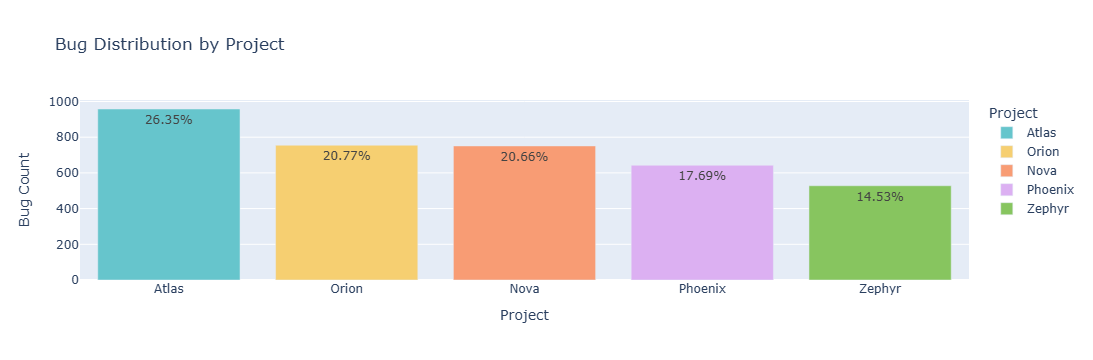

In [34]:
# Count bugs by project
bug_counts = df["project"].value_counts().reset_index()
bug_counts.columns = ["project", "count"] #rename the columns
bug_counts["share"] = ((bug_counts["count"]/ len(df)) * 100).round(2)
bug_counts["label"] = bug_counts["share"].astype(str) + "%"

fig = px.bar(
    bug_counts,
    x="project",
    y="count",
    color="project",  # Assigns a unique color to each bar
    text = "label", #displays percentage on the bar
    title="Bug Distribution by Project",
    labels={"project": "Project", "count": "Bug Count","label":"Bug Percentage"},
    color_discrete_sequence=px.colors.qualitative.Pastel,
   
)

fig.show()

Atlas have the largest share of issues at 26.35%(958 bugs), followed by orion at 20.77%(755 bugs), nova (20.66%), Phoenix (17.69%), and Zephyr (14.53%).

#### Bugs Escape Percentage by Project

In [35]:
# escape percentages by project
escape_rates = df.groupby('project')['escaped_to_production'].mean() * 100
print(escape_rates.round(2))

project
Atlas      13.05
Nova       11.05
Orion      11.52
Phoenix    10.89
Zephyr      7.95
Name: escaped_to_production, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_11488\3738025442.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### Severity Breakdown (Bar Chart)

In [36]:
total_severity_counts = df["severity"].value_counts()
# Calculate bug share percentage
total_severity_share = ((total_severity_counts / len(df)) * 100).round(2)

print(
    pd.DataFrame({"Severity Count": total_severity_counts, "Share (%)": total_severity_share})
)

          Severity Count  Share (%)
severity                           
Major               1097      30.18
Minor                828      22.78
Critical             456      12.54
Trivial              305       8.39
High                 281       7.73
Unknown              208       5.72
Medium               197       5.42
Blocker              138       3.80
Low                  125       3.44


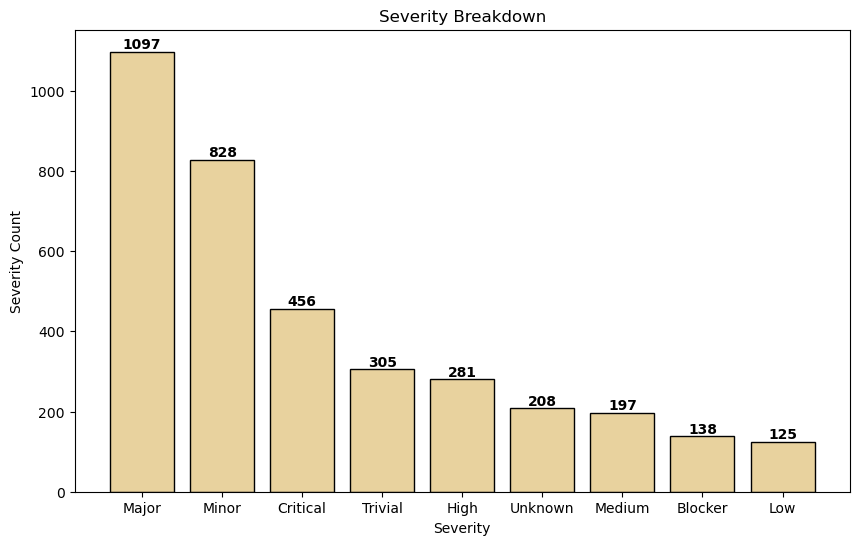

In [37]:

severity_counts = df["severity"].value_counts().reset_index()
severity_counts.columns = ["severity", "count"]
plt.figure(figsize=(10, 6))
bars=plt.bar(
    severity_counts["severity"],
    severity_counts["count"],
    color="#e8d29e", 
    edgecolor="black",
)
plt.bar_label(bars,fontweight="bold")
plt.title("Severity Breakdown")
plt.xlabel("Severity")
plt.ylabel("Severity Count")
plt.show()

 Major (30.18%) and Minor (22.72%) represent over half of all issues, while blocker(3.80) and Low(3.447) share small amount of issues

#### finding primary root causes using pie chart

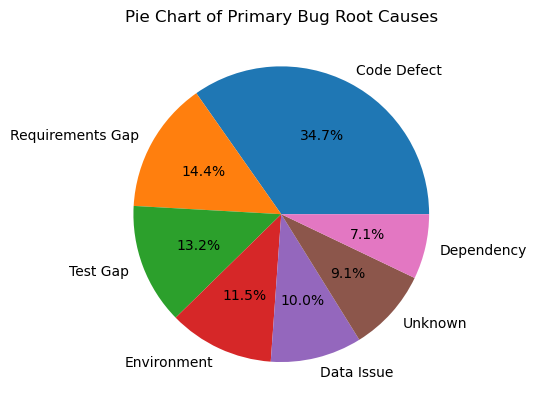

In [38]:
root_cause_counts = df["root_cause"].value_counts()
plt.pie(
    root_cause_counts.values,
    labels=root_cause_counts.index,
    autopct="%1.1f%%"
)
plt.title("Pie Chart of Primary Bug Root Causes")
plt.show()

 Code Defects dominate at 34.7%, followed by Requirements Gaps (14.4%), Test Gaps (13.2%), Environment issues (11.5%), and Data Issues (10.0%).

### Production Escape Rate and Customer Impact Distribution of Escaped Bugs using subplot(Pie Chart)

finding escaped bug count,caught bugs and escape rate

In [39]:
total_bugs = len(df)

# Count of bugs that escaped to production
escaped_bugs = df["escaped_to_production"].sum()

# Count of bugs caught by QA
caught_bugs = total_bugs - escaped_bugs




# Calculate the escape percentage
escape_rate = ((escaped_bugs / total_bugs) * 100).round(2)

print("Total Bugs:",total_bugs)
print("Escaped Bugs:",escaped_bugs)
print("Caught by QA:",caught_bugs)
print("Escape Rate:",escape_rate)

Total Bugs: 3635
Escaped Bugs: 407
Caught by QA: 3228
Escape Rate: 11.2


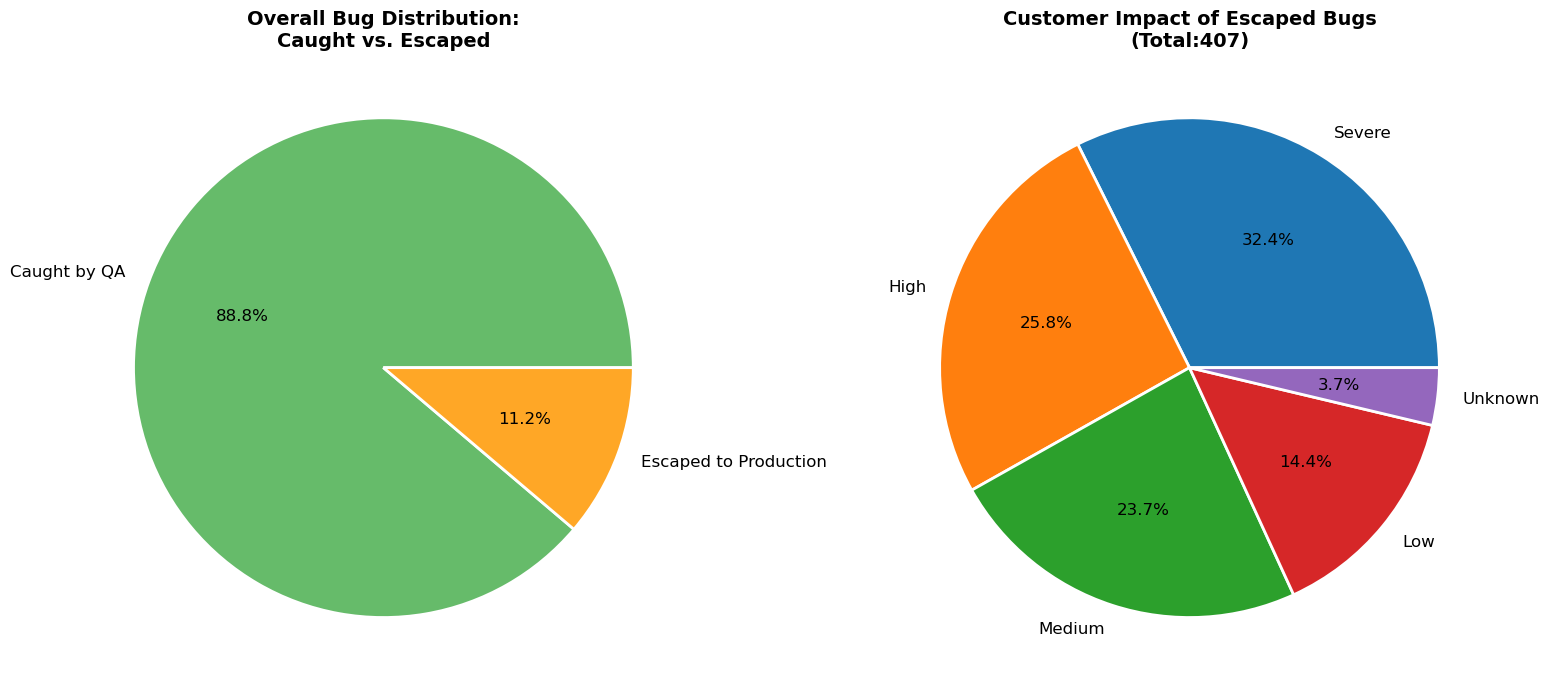

In [40]:
# initialize a dual panel figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

escape_counts = df["escaped_to_production"].value_counts()

# creating first pie chart
axes[0].pie(
    escape_counts.values,
    labels= ["Caught by QA", "Escaped to Production"],
    autopct="%1.1f%%",
    colors = ["#66bb6a", "#ffa726"],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12},
)

axes[0].set_title("Overall Bug Distribution:\nCaught vs. Escaped", fontsize=14, fontweight="bold")

impact_counts = df["customer_impact"].value_counts()

# creating second pie chart
axes[1].pie(
    impact_counts.values,
    labels= ["Severe", "High", "Medium", "Low", "Unknown"],
    autopct="%1.1f%%",
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12},
)

axes[1].set_title("Customer Impact of Escaped Bugs\n(Total:407)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

 11.2% of all logged issues escaped to production,Out of the 407 escaped bugs, 32.4%  caused Severe customer impact, and 25.8% caused High impact.

### Number of Bugs Across Sprint using line chart
 Counting the bugs in each sprint

In [41]:
total_severity_counts = df["sprint"].value_counts()
print(total_severity_counts)

sprint
Sprint 22    149
Sprint 4     145
Sprint 15    144
Sprint 13    144
Sprint 14    144
Sprint 7     143
Sprint 9     143
Sprint 6     139
Sprint 27    136
Sprint 8     135
Sprint 5     135
Sprint 21    134
Sprint 17    133
Sprint 18    129
Sprint 12    129
Sprint 28    128
Sprint 20    126
Sprint 10    126
Sprint 19    125
Sprint 24    123
Sprint 2     119
Sprint 11    118
Sprint 3     118
Sprint 16    118
Sprint 1     115
Sprint 23    114
Sprint 25    112
Sprint 26    111
Name: count, dtype: int64


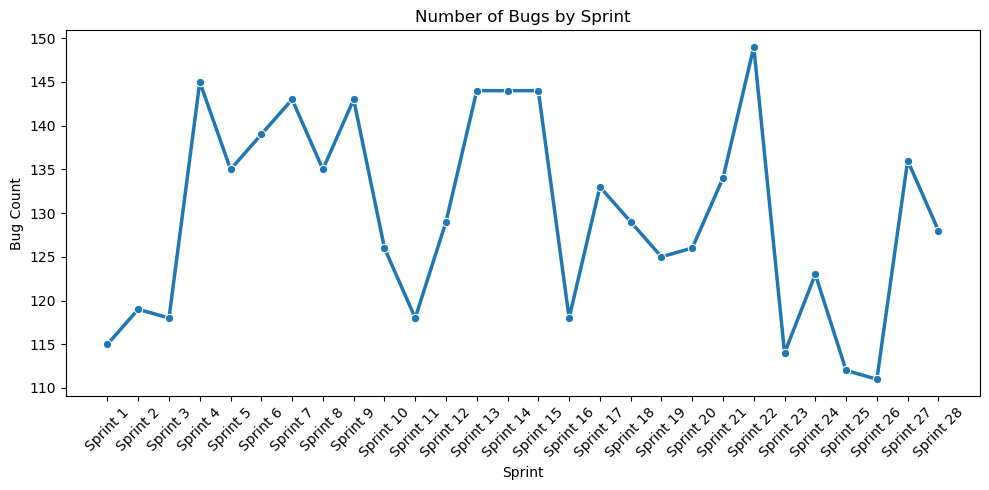

In [42]:
sprint_order = sorted(df["sprint"].dropna().unique(), key=lambda x: int(''.join(filter(str.isdigit, str(x)))))

# 2. Set categorical type with ordered=True
df["sprint"] = pd.Categorical(df["sprint"], categories=sprint_order, ordered=True)
sprint_counts = df["sprint"].value_counts().sort_index() #sort by index label
plt.figure(figsize=(10, 5))
sns.lineplot(
    x=sprint_counts.index,
    y=sprint_counts.values,
    marker="o",
    linewidth=2.5
)
plt.title("Number of Bugs by Sprint")
plt.xlabel("Sprint")
plt.ylabel("Bug Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 



Sprint 22 recorded the absolute highest bug count, reaching 149 bugs.Sprint 26 recorded the lowest bug count(111 bugs).

### Monthly Bug Reporting Trend using Interactive Line Chart

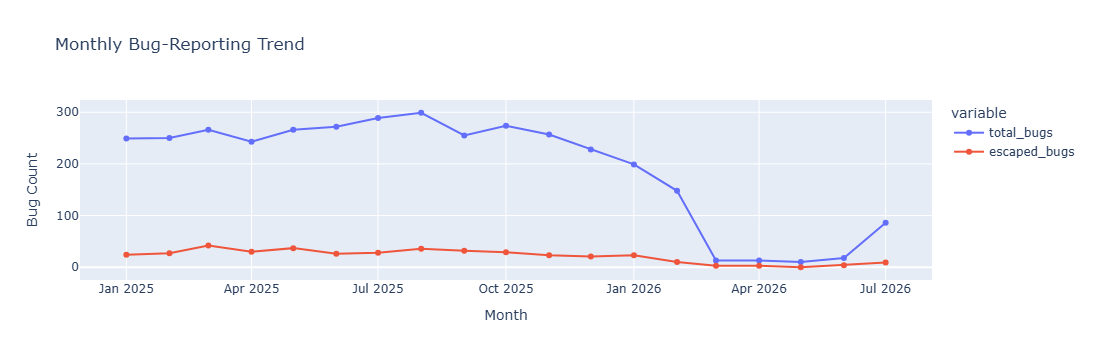

In [43]:

df["year_month"] = df["created_date"].dt.to_period("M").astype(str)
monthly_df = (
    df.groupby("year_month")
    .agg(
        total_bugs=("bug_id", "count"),
        escaped_bugs=("escaped_to_production", "sum"),
    )
    .reset_index()
)
fig = px.line(
    monthly_df,
    x="year_month",
    y=["total_bugs", "escaped_bugs"],
    markers=True,
    title="Monthly Bug-Reporting Trend",
    labels={"year_month": "Month", "value": "Bug Count"},
)

fig.show()

 Throughout 2025, bug counts remained steady and high at 250–300 per month (peak in August), with 20–45 bugs escaping to production monthly. In early 2026, bug reports dropped from 200 in January down to just 13 in March, staying under 20 per month through June with almost no escaped bugs. Finally, total bugs reprts raised back up to 86 in July 2026, though escaped bugs remained low at around 9.

### Resolution time by severity

In [44]:
summary_stats = df.groupby("severity")["resolution_days"].describe().round(2)
print(summary_stats[["min", "25%", "50%", "75%", "max", "mean"]])

          min  25%   50%    75%   max   mean
severity                                    
Blocker   0.0  8.0  17.0  29.00  38.5  18.48
Critical  0.0  6.0  11.0  18.25  38.5  13.61
High      0.0  7.0  12.0  19.00  38.5  13.58
Low       0.0  6.0  10.0  17.00  38.5  12.35
Major     0.0  7.0  11.0  19.00  38.5  13.70
Medium    0.0  7.0  12.0  19.00  38.5  14.04
Minor     0.0  6.0  11.0  18.00  38.5  13.15
Trivial   0.0  6.0  10.0  17.00  38.5  12.52
Unknown   0.0  6.0  11.0  18.00  38.5  13.36


C:\Users\HP\AppData\Local\Temp\ipykernel_11488\1458176735.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



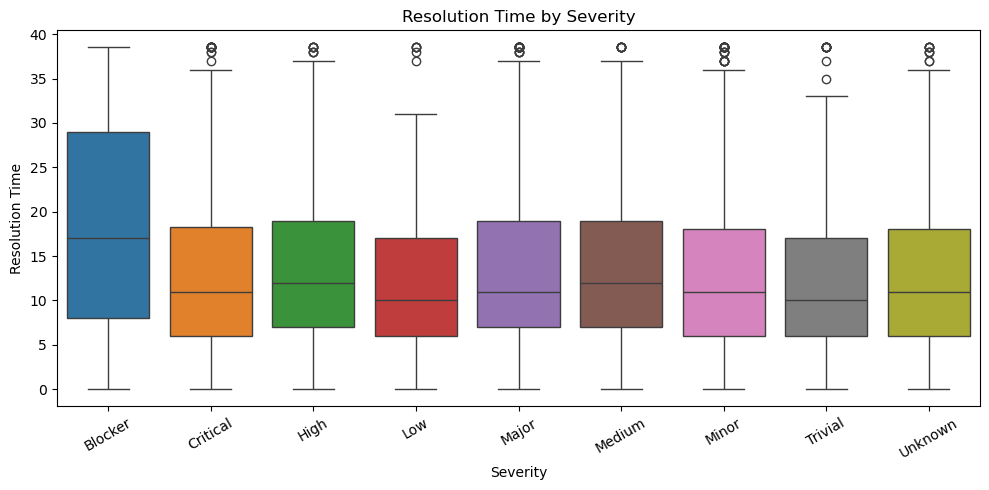

In [45]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x=df["severity"],
    y=df["resolution_days"],
    hue=df["severity"],
    legend=False ,
)
plt.title("Resolution Time by Severity")
plt.xlabel("Severity")
plt.ylabel("Resolution Time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Blocker bugs take the longest to fix, taking about 17.96 days on average. All other bugs (from Critical to Trivial) take about 11–14 days average to resolve

### Defect Count by Environment

In [46]:
# Calculate metrics grouped by environment
env_summary = (
    df.groupby("environment").agg(
        bug_count=("bug_id", "count"),
        total_executed=("test_cases_executed", "sum"),
        total_failed=("failed_test_cases", "sum"),
    ).reset_index()
)

# Calculate test failure rate (%)
env_summary["failure_rate"] = ((env_summary["total_failed"] / env_summary["total_executed"]) * 100).round(2)

print(env_summary)

  environment  bug_count  total_executed  total_failed  failure_rate
0         Dev        546         45786.0        4379.0          9.56
1  Production        537         45211.0        4967.0         10.99
2          Qa        891         74813.0        7005.0          9.36
3     Staging        946         78631.0        8026.0         10.21
4         Uat        354         30218.0        2852.0          9.44
5     Unknown        361         29280.0        3114.0         10.64


C:\Users\HP\AppData\Local\Temp\ipykernel_11488\695443222.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



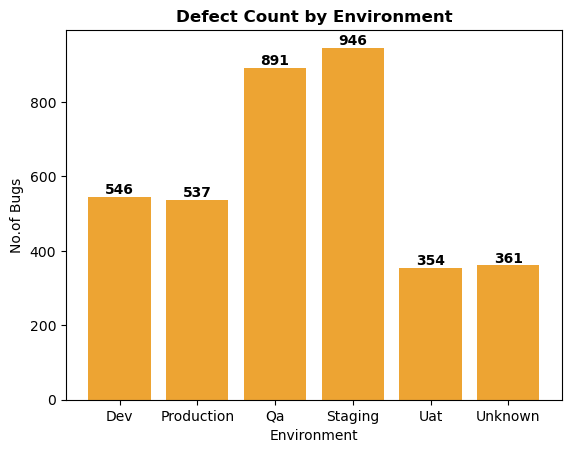

In [47]:
bars=plt.bar(
    env_summary["environment"],
    env_summary["bug_count"],
    color="#eda433",
    #edgecolor="black",
)
plt.bar_label(bars,fontweight="bold")
plt.title("Defect Count by Environment",fontweight="bold")
plt.xlabel("Environment")
plt.ylabel("No.of Bugs")
plt.show()

Staging (946) and QA (891) caught the most defects before launch. 537 bugs escaped to Production, directly affecting users.Dev (546) and UAT (354) logged fewer total issues.361 bugs marked Unknown show a need for better logging practices.

### Test Failure Rate by Environment

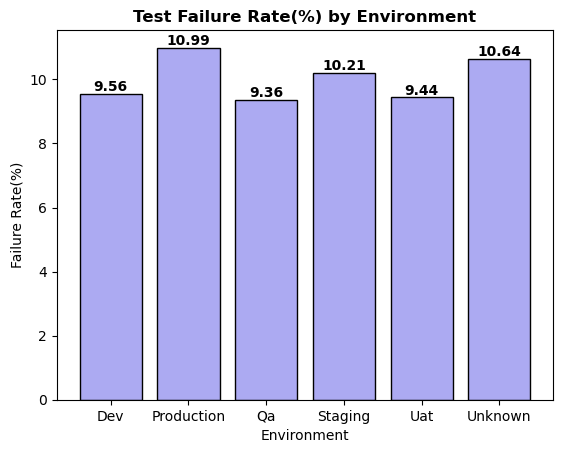

In [48]:
bars=plt.bar(
    env_summary["environment"],
    env_summary["failure_rate"],
    color="#acaaf2", 
    edgecolor="black",
)
plt.bar_label(bars,fontweight="bold")
plt.title("Test Failure Rate(%) by Environment",fontweight="bold")
plt.xlabel("Environment")
plt.ylabel("Failure Rate(%)")
plt.show()

Production has the highest test failure rate (10.99%),followed by Unknown also showing a high failure rate of 10.64%. Other environments (Dev, QA, Staging, UAT) are all very close, hovering around 9% to 11%.

### Resolution Days Bottlenecks by Team & Severity using Heatmap

In [49]:
# Bottlenecks by Team & Severity
team_severity = df.pivot_table(
    index="team", columns="severity", values="resolution_days", aggfunc="mean"
).round(1)

team_severity


C:\Users\HP\AppData\Local\Temp\ipykernel_11488\14947600.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



severity,Blocker,Critical,High,Low,Major,Medium,Minor,Trivial,Unknown
team,,,,,,,,,
Core Web,21.4,12.6,14.4,12.6,13.7,13.3,13.8,14.1,12.5
Data,19.1,13.9,12.5,11.8,12.9,13.7,12.9,10.2,15.5
Mobile,18.5,14.6,14.8,12.6,14.0,12.6,13.3,12.8,13.7
Payments,18.3,13.9,13.8,11.9,13.7,16.5,14.0,11.6,14.9
Platform,19.5,14.4,12.9,10.9,14.4,13.4,11.6,13.1,9.6
Qa Automation,15.2,12.4,12.4,14.5,13.5,13.4,13.1,12.8,13.8


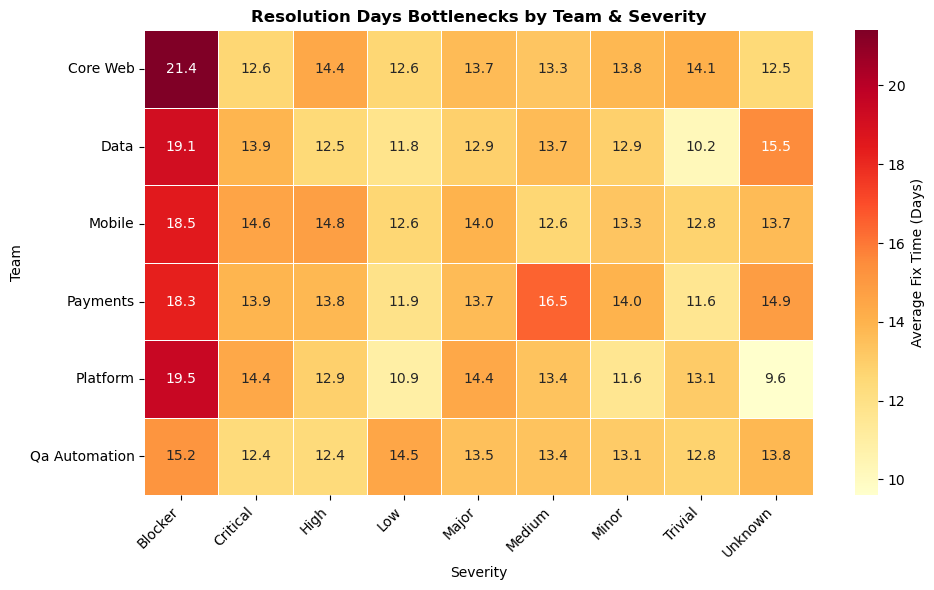

In [50]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    team_severity,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",  # Darker red = severe bottleneck
    cbar_kws={"label": "Average Fix Time (Days)"},
    linewidths=0.5
)

plt.title("Resolution Days Bottlenecks by Team & Severity", fontweight="bold")
plt.xlabel("Severity")
plt.ylabel("Team")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Blocker Severity Peak: Blocker issues take the longest to resolve across all teams, ranging from 15.2 to 21.4 days, while non-blocker issues generally range between 9.6 and 16.5 days.
Core Web (21.4 days) and Platform (19.5 days) take the longest to fix Blocker bugs.
Payments takes longer to fix Medium bugs (16.5 days) than Critical or High ones.
 
QA Automation is the best performer which resolves Blockers fastest (15.2 days).

### __Key Findings__

The dataset is an software engineering quality assurance and issue-tracking log contains 3,690 bug records across 30 attributes, representing software issue tracking, testing execution, agile sprint delivery, and defect lifecycle metrics.

__1. Sprint & Project Defect Distribution__

  
• Atlas leads in total defect volume with 26.35% (958 bugs), followed by Orion (20.77%) and Nova     (20.66%). Zephyr had the lowest count at 14.53%.

  
• Defect volume averaged 130 bugs per sprint across 28 cycles .Sprint 22 recorded the absolute highest bug count, reaching 149 bugs. Sprint 26 recorded the lowest bug count (111 bugs). holding steady at 144 bugs from Sprint 13 to 15

__2.	Production Escapes & Customer Impact__


•	There are 407 bugs marked as escaped to production, equivalent to approximately 11.2% of the dataset. The highest project-level escape rate belongs to Atlas at 13.05%, followed by Orion at 11.52%, Nova at 11.05%, Phoenix at 10.89%, and Zephyr at 7.95%. Atlas is therefore the most important project for immediate escape-reduction work, especially because it also has the highest bug volume with 958 records.

•	11.2% of all logged issues escaped to production. Out of the 407 escaped bugs, 32.4% caused Severe customer impact, and 25.8% caused High impact.	

•	Of the 407 total production escapes, high-severity defects overwhelmingly dominate the dataset, with 58.2% falling into critical categories—comprising Severe (32.4%) and High (25.8%) customer impacts. In contrast, low-impact issues are relatively rare, representing just 14.4% of escaped bugs. The remaining production leaks consist of Medium impact defects at 23.7%, with 3.7% of issues remaining unclassified

__3.	Defect Classification & Root Causes__
  
•	The majority of reported defects fall into Major (30.18%) and Minor (22.78%) categories. Critical and Blocker defects account for 12.54% and 3.80%, respectively.	

•	Code Defects dominate at 34.7%, followed by Requirements Gaps (14.4%), Test Gaps (13.2%), Environment issues (11.5%), and Data Issues (10.0%).	

__4.	Resolution Time & Team Performance__
  
•	Blocker bugs take the longest to fix, taking about 18 days on average. All other bugs (from Critical to Trivial) take about 11.2 and 13.9 days days average to resolve.	

•	Blocker issues take the longest resolution days across all teams (17.8–20.6 days) and 9–16 days for others. Core Web (20.6 days) and Platform (19.2 days) take the longest to fix Blocker bugs. Payments takes longer to fix Medium bugs (16 days) than Critical or High ones. QA Automation is the best performer which resolves Blockers fastest (14.7 days).		

__5.	Environment & Testing Efficiency__

•	Staging (946) and QA (891) caught the most defects before launch. 537 bugs escaped to Production, directly affecting users. Dev (546) and UAT (354) logged fewer total issues. 361 bugs marked Unknown show a need for better logging practices.		

•	Production has the highest test failure rate (10.99%), followed by Unknown also showing a high failure rate of 10.64%. Other environments (Dev, QA, Staging, UAT) are all very close, hovering around 9% to 11%.

__6.	Bug Reporting and Escape__

•	Throughout 2025, bug counts remained steady and high at 250–300 per month (peak in August), with 20–45 bugs escaping to production monthly. In early 2026, bug reports dropped from 200 in January down to just 13 in March, staying under 20 per month through June with almost no escaped bugs. Finally, total bug reports raised back up to 86 in July 2026, though escaped bugs remained low at around 9.


### __Recommendations__

• Create a clear plan to handle high-priority and severity bugs bugs right away so they do not take as long to get fixed.

• Enforce stricter code reviews and clearer requirements before testing.

• Upgrade QA regression suites to catch bugs before users do

• Find environments where tests fail often, clean up broken tests, and prevent developers from getting stuck waiting.

### __Conclusion__

Systematic tracking of bug resolution times, root causes, and environment failures allows software engineering teams to catch critical bottlenecks early. By improving pre-testing code quality and stopping defects from reaching production, teams achieve faster release cycles, cleaner data logging, and a more reliable product for end users.